In [745]:
from escripts import eMCMC
import importlib
from escripts import eplots
Plotting = eplots.Plotting()
from pandas.plotting import table
import zeus21
from escripts import cosmo_calc
from astropy import units as u
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
import time
import matplotlib.gridspec as gridspec

In [505]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [506]:
custom_params = {}

In [507]:
param_data = eMCMC.build_param_data(custom_params)

In [526]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [527]:
my_UVLF = eMCMC.UVLF(file_names, data_labels, param_data)

In [528]:
ICs = my_UVLF.generate_ICs()

In [529]:
# Run MCMC
t = time.time()
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)
print(time.time()-t)

100.14070296287537


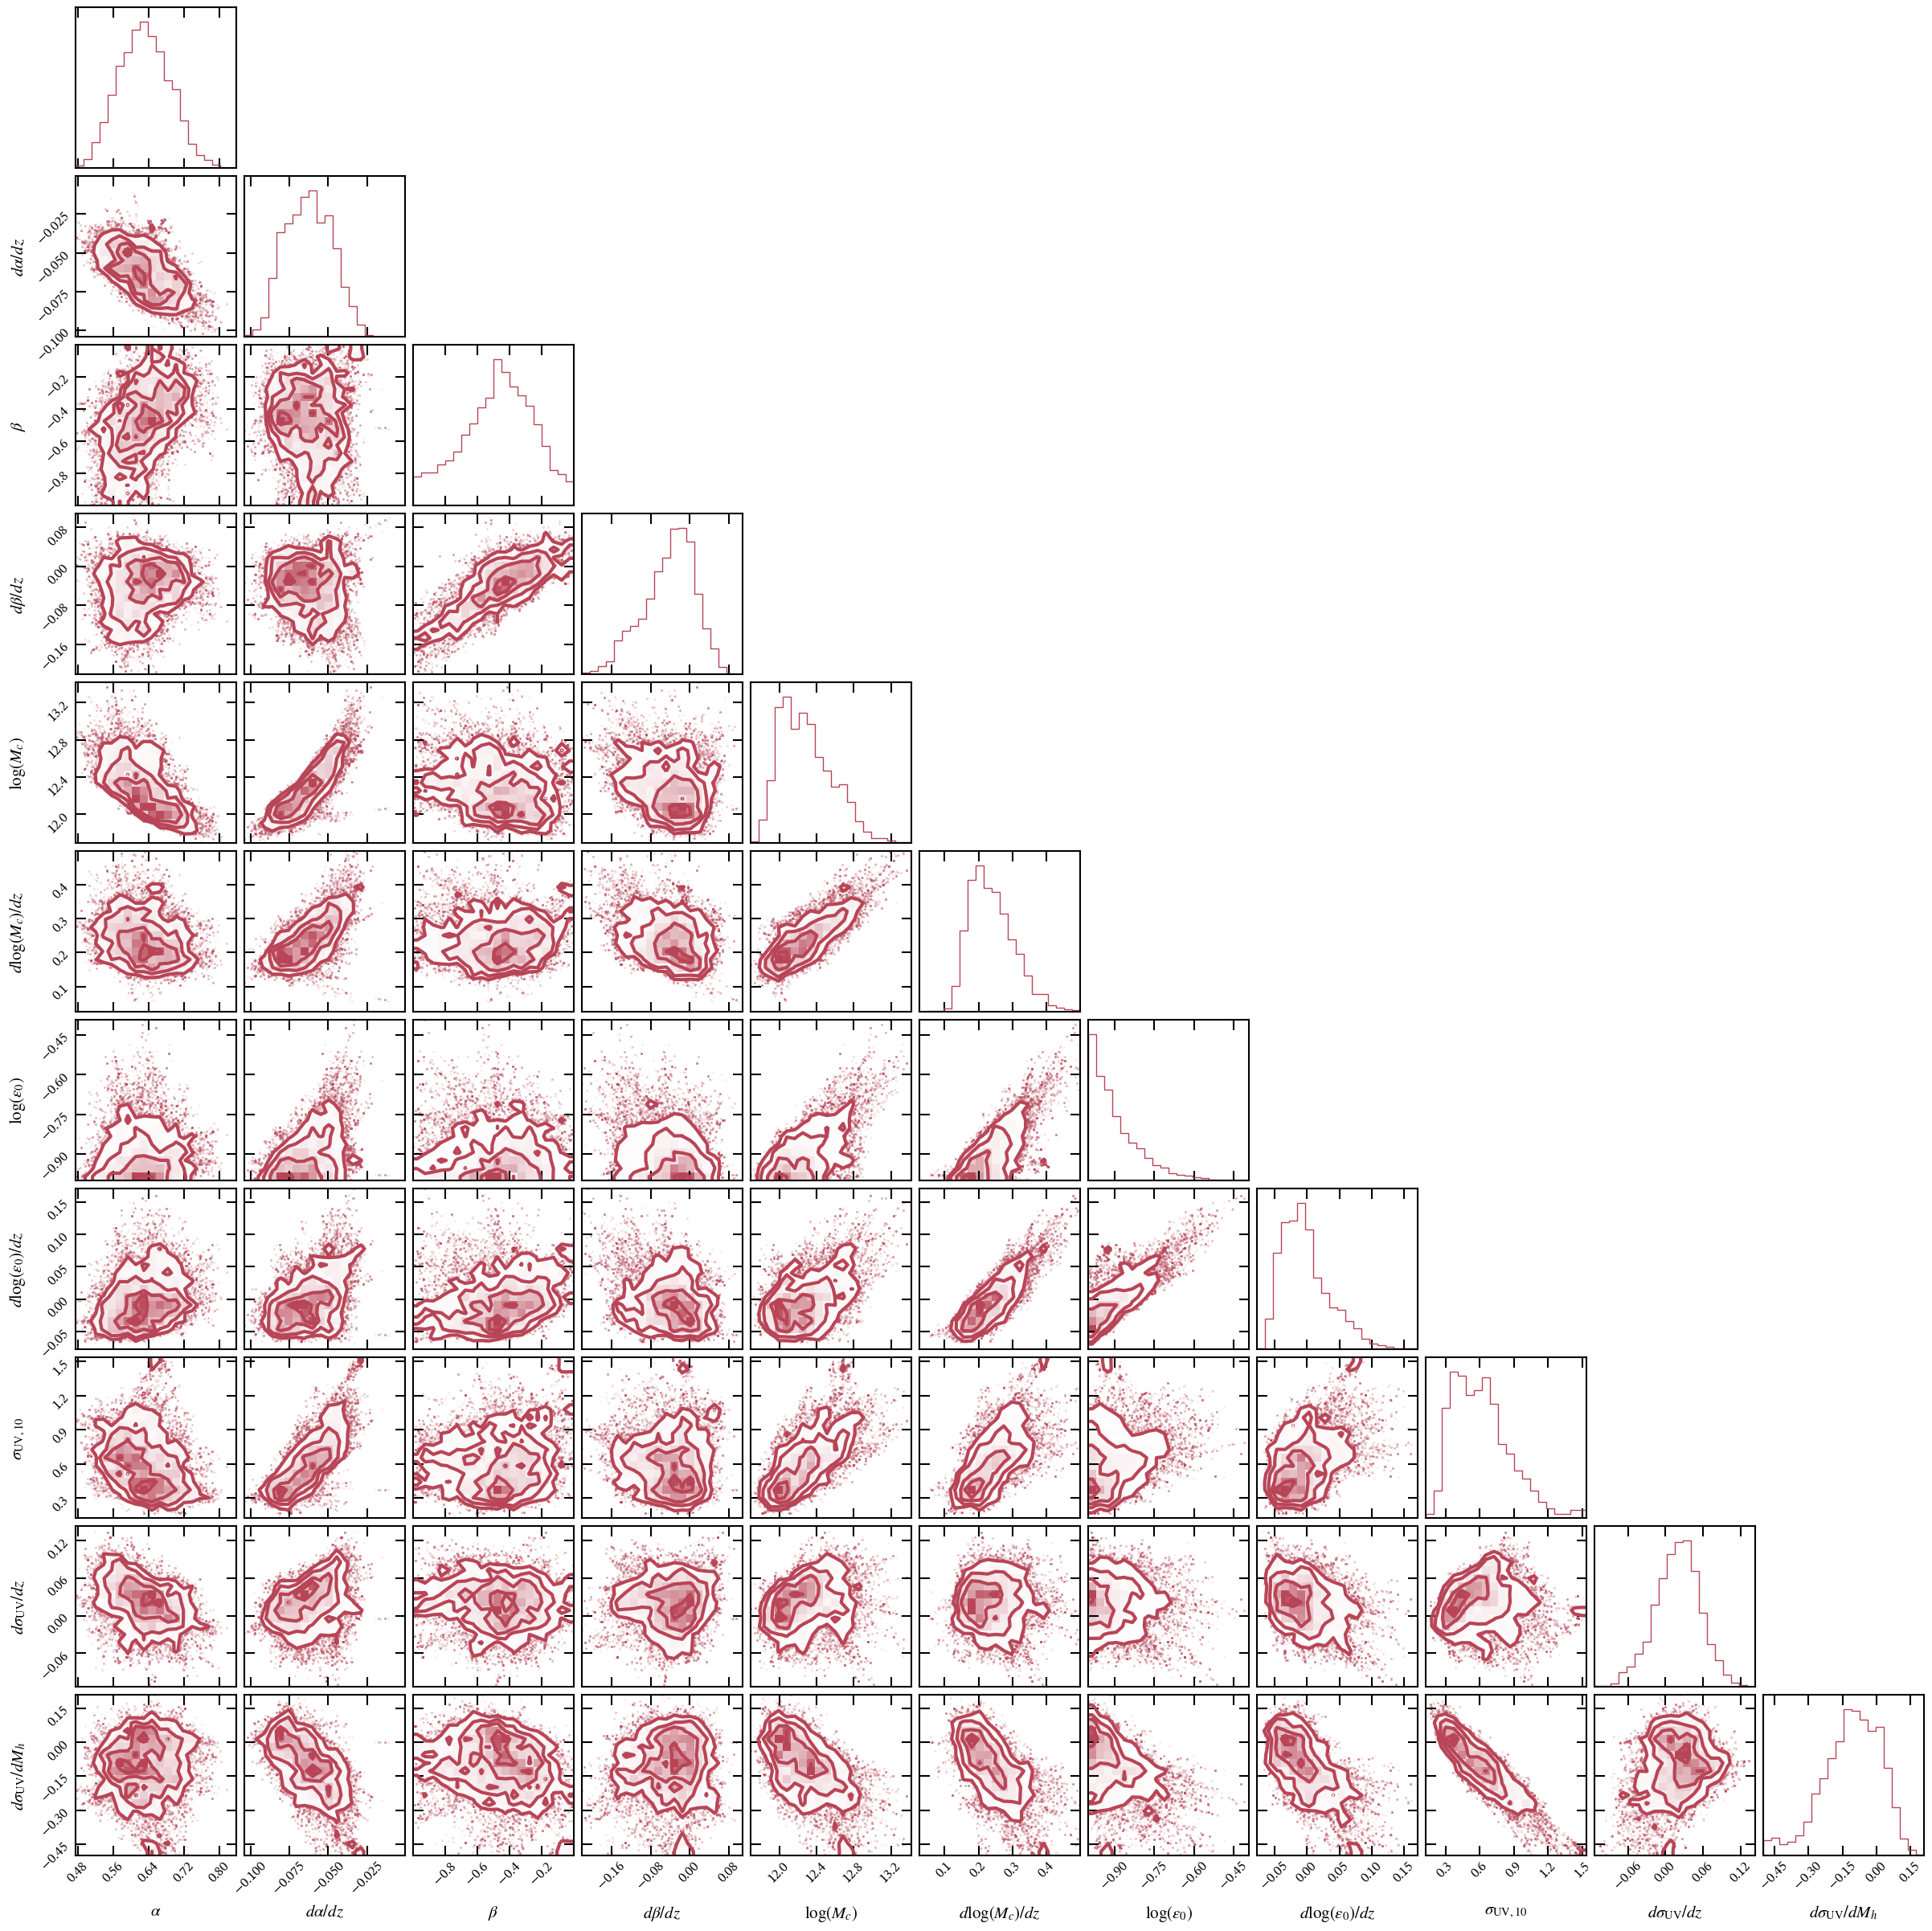

In [530]:
corner = Plotting.plot_corner(samples, my_UVLF)
#corner.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/corner.png', bbox_inches='tight')

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:145: RuntimeWarning: invalid value encountered in log10
  ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat, plot_xerr,sample)), alpha=nsamples/3500, color = self.red,
/Users/eb35267/Desktop/code/home/escripts/eplots.py:145: RuntimeWarning: divide by zero encountered in log10
  ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat, plot_xerr,sample)), alpha=nsamples/3500, color = self.red,


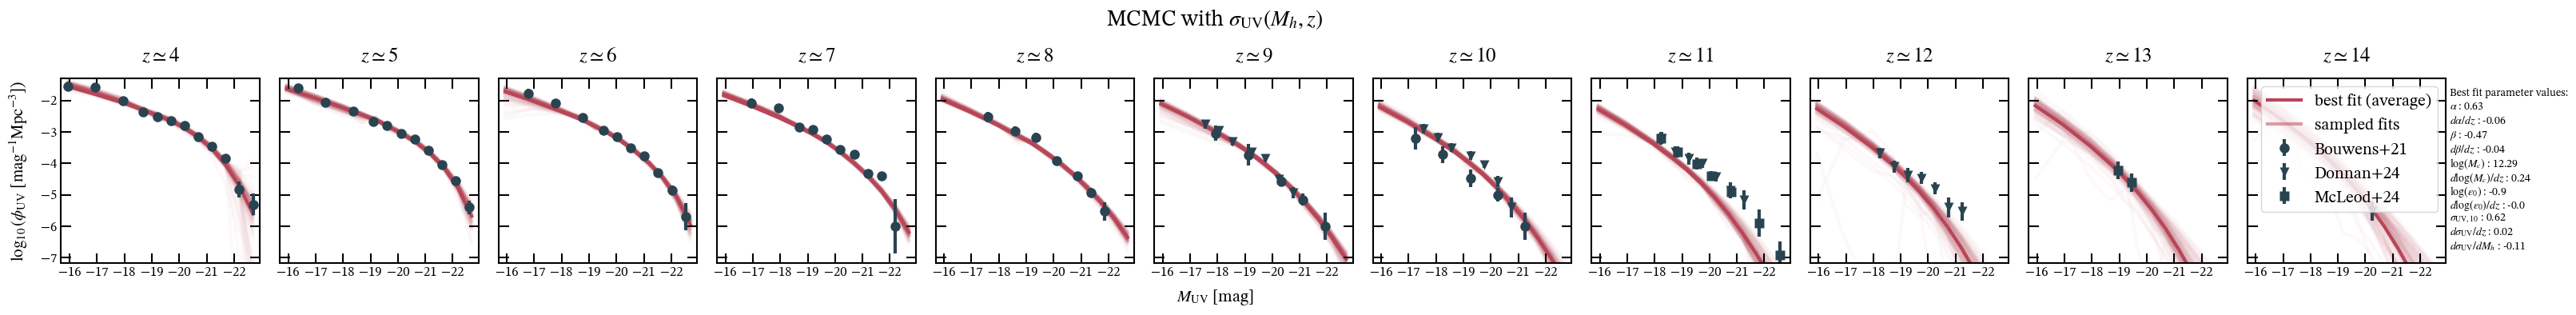

In [565]:
te_plot = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'MCMC with $\sigma_{\rm{UV}}(M_h, z)$')
#te_plot.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/model_jwst_data.png', bbox_inches='tight')

## Best fit stuff

In [554]:
old_best_fit = [0.67, 0.01, -0.42, 0.13, 12.15, 0.08, -0.92, -0.0, 0.66, -0.06, -0.19]

In [550]:
best_fit, param_labels = my_UVLF.get_best_fit(samples)

In [555]:
jm_conste = [0.61, -0.01, -1.91, 0.08, 12.03, 0.03, '-', '-',  0.65, -0.03, 0]
jm_consts = [.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, '-', '-', 0]

In [588]:
df = eMCMC.make_table([best_fit, old_best_fit, jm_conste, jm_consts], param_labels, 
                      [r'MCMC, HST & JWST data', 'MCMC, HST data', 
                       r'Muñoz+23, piecewise $\epsilon$', r'Muñoz+23, piecewise $\sigma_{\rm{UV}}$'])

In [589]:
df

,"MCMC, HST & JWST data","MCMC, HST data","Muñoz+23, piecewise $\epsilon$","Muñoz+23, piecewise $\sigma_{\rm{UV}}$"
$\alpha$,0.63,0.67,0.61,0.74
$d\alpha/dz$,-0.06,0.01,-0.01,0.03
$\beta$,-0.47,-0.42,-1.91,-1.76
$d\beta/dz$,-0.04,0.13,0.08,-0.02
$\log(M_c)$,12.29,12.15,12.03,11.84
$d\log(M_c)/dz$,0.24,0.08,0.03,-0.02
$\log(\epsilon_0)$,-0.9,-0.92,-,-1.08
$d\log(\epsilon_0)/dz$,-0.0,-0.0,-,-0.07
"$\sigma_{\rm{UV}, 10}$",0.62,0.66,0.65,-
$d\sigma_{\rm{UV}}/dz$,0.02,-0.06,-0.03,-


In [657]:
12.29-(0.24*6)

10.85

In [583]:
importlib.reload(eplots)
Plotting = eplots.Plotting()

/Users/eb35267/Desktop/code/home/escripts/eplots.py:167: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')
/Users/eb35267/Desktop/code/home/escripts/eplots.py:219: SyntaxWarning: invalid escape sequence '\c'
  for sample, label in zip(best_fits, fit_labels): #, self.hex_colors[:len(UVLF_objects)]:
/Users/eb35267/Desktop/code/home/escripts/eplots.py:230: SyntaxWarning: invalid escape sequence '\s'
  ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')


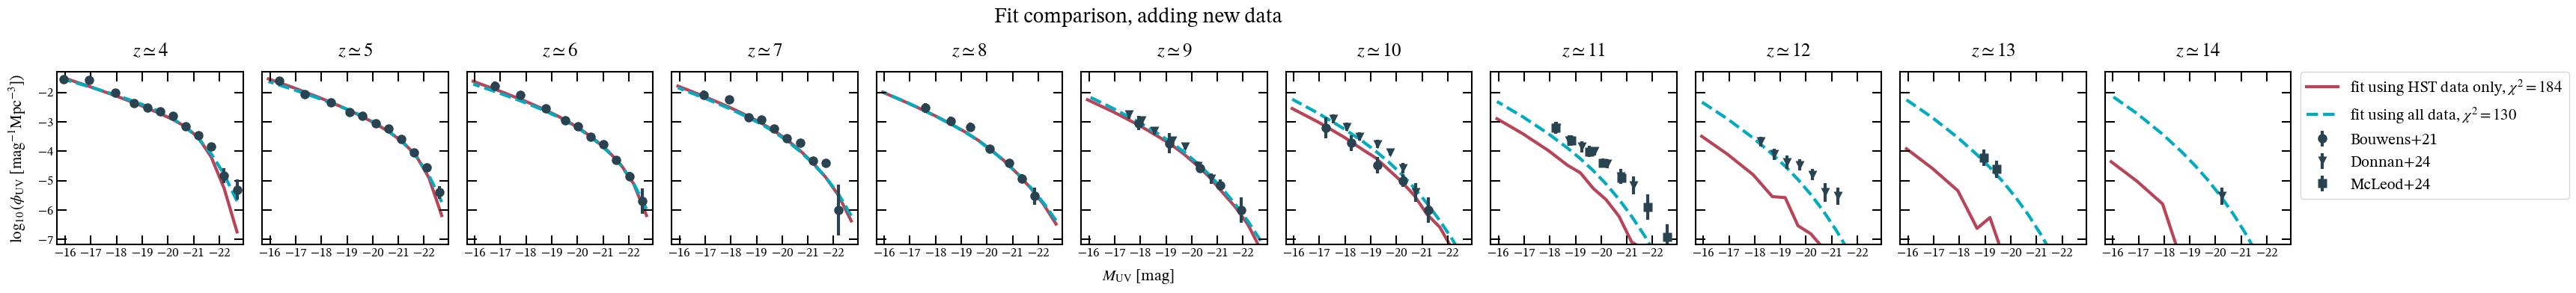

In [586]:
comp_fig = Plotting.compare_fits(file_names, data_labels, [old_best_fit, best_fit], 
                                 fit_labels = [r'fit using HST data only', r'fit using all data'], 
                                 title = 'Fit comparison, adding new data')

In [587]:
#comp_fig.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/compare_hst_jwst.png', bbox_inches='tight')

# Interpreting the time evolution of parameters

In [683]:
def get_sfe_evolution(my_UVLF, best_fit, zmax, Ms, steps):
    zeus_params = cosmo_calc.get_params()
    ClassyCosmo, CosmoParams = cosmo_calc.get_CosmoParams(zeus_params)

    fstars = []
    for Mh in Ms:
        zs, Mh_i = Mz(zmax, Mh, params, CosmoParams, steps)
        fstar_i = [calc_evolving_SFE(my_UVLF, best_fit, z, Mh) for (z, Mh) in zip(zs, Mh_i)]
        fstars.append(fstar_i)

    return zs, fstars
    
    
def Mz(zmax, M0, params, CosmoParams, steps):
    Ms = np.zeros(steps+1)
    Ms[0] = 10**M0
    zs = np.linspace(0, zmax, steps+1)
    dz = z/(steps+1)
    for i in range(steps):
        # Multiply dM/dt by dt/dz to get M_dot
        M_dot = calc_M_dot(Ms[i], params, zs[i]) / ((1+zs[i]) * (zeus21.Hub(CosmoParams, zs[i])*u.km/(u.s*u.Mpc)).to(u.year**-1).value) 
        # Had to take out a negative here to make it work; not sure why. Normally dt/dz would include a -(1+z)
        Ms[i+1] = Ms[i] - (M_dot * dz)

    return zs, np.log10(Ms)

def calc_M_dot(M_h, params, z = 0):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

def calc_evolving_SFE(my_UVLF, best_fit, z, Mh):
    params = my_UVLF.time_evolution(best_fit, z)
    Astro_Parameters = my_UVLF.param_wrapper(params)
    SFE = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mh)
    return SFE

In [792]:
def plot_sfe_evolution(my_UVLF, fits, labels, zmax = 14, plot_zlims=(4,14), Ms = np.arange(10, 15, 1), steps = 100):
    
    fig = plt.figure(figsize=(12,4))
    # Define the ratio between ax1 and cax
    outer = gridspec.GridSpec(1, 2, width_ratios=[30, 1], wspace=0.05) 
    # Define the ratio between ax1 and ax0
    inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], width_ratios=[1, 1], wspace=0.15) 
    
    ax0 = fig.add_subplot(inner[0])
    ax1 = fig.add_subplot(inner[1])
    cax = fig.add_subplot(outer[1])
    
    gradient = eplots.interpolate_colors([Plotting.red, Plotting.navy], len(Ms), show_plot = False)
    cmap = ListedColormap(gradient)
    norm = BoundaryNorm(np.arange(min(Ms), max(Ms)+2, 1), cmap.N)
    
    for fit, label, ls, lw in zip(fits, labels, ['-', 'dashed'], [3, 2]):
        
        zs, fstar = get_sfe_evolution(my_UVLF, fit, zmax, Ms, steps)
        
        ax1.plot(0, 0, ls = ls, color = 'black', lw = lw, label = label) # Make invisible line for the legend purposes
        
        for fstar_i, Mi in zip(fstar, Ms):
            color = cmap(norm(Mi))
            ax0.plot(zs[zs>plot_zlims[0]], np.array(fstar_i)[zs>plot_zlims[0]], ls = ls, color = color, lw = lw)
            sig, dsigdz, dsigdM = fit[8:11]
            ax1.plot(zs, (sig + (dsigdz*(zs-8)))+ (dsigdM*(Mi-10)), ls = ls, color = color, lw = lw)
    
    
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, cax=cax, ticks=np.array(Ms)+0.5, boundaries=Ms, format='%1i')
    cbar.set_label(r'$\log_{10}(M_h/M_{\odot})$ at $z=0$') 

    ax1.legend()
    ax0.set_xlim(plot_zlims)
    ax1.set_xlim(plot_zlims)
    ax0.set_ylabel('SFE')
    ax1.set_xlabel('redshift')
    ax1.set_ylabel(r'$\sigma_{\rm{UV}}$', labelpad = -5)
    ax0.set_xlabel('redshift')
    ax1.set_xlabel('redshift')

    return fig

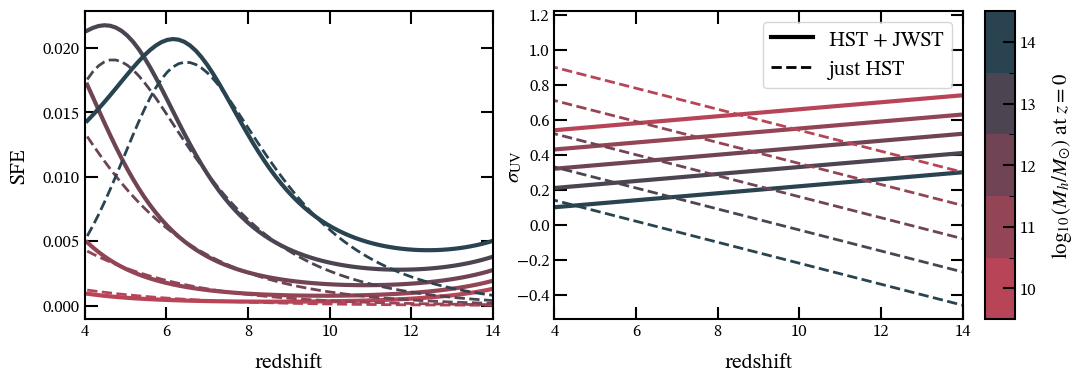

In [794]:
sfe_plot = plot_sfe_evolution(my_UVLF, [best_fit, old_best_fit], labels = ['HST + JWST', 'just HST'])
#sfe_plot.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/SFE_sig_HST_vs_JWST.png', bbox_inches='tight')

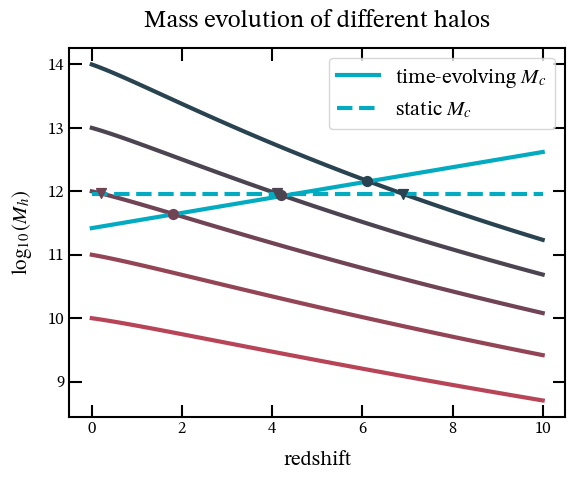

In [656]:
# fig, ax = plt.subplots()
# cross_ev = []
# cross_const = []
# for Mi, color in zip(Ms, gradient):
#     zi, Ms_i = M(10, Mi, params, CosmoParams, steps = steps)
#     ax.plot(zi, Ms_i, ls = 'solid', color = color)
#     mc = 12.38 + (zi-8)*0.12
#     cross_ev_i = np.where(Ms_i > mc)[0]
#     cross_ev.append(cross_ev_i)
#     if len(cross_ev_i) >= 1:
#         ax.scatter(zi[cross_ev_i][-1], Ms_i[cross_ev_i][-1], zorder = 10, s = 50, color = color)
#     cross_const_i = np.where(Ms_i > 11.95)[0]
#     cross_const.append(cross_const_i)
#     if len(cross_const_i)>=1:
#         ax.scatter(zi[cross_const_i][-1], Ms_i[cross_const_i][-1], zorder = 10, s = 50, color = color, marker='v')

# ax.plot(zi, mc, color = Plotting.turquoise, label = r'time-evolving $M_c$') 
# ax.plot(zi, np.full_like(zi, 11.95), color = Plotting.turquoise, label = 'static $M_c$')
# ax.set_xlabel('redshift')
# ax.set_ylabel(r'$\log_{10}(M_h)$')
# ax.set_title('Mass evolution of different halos')
# ax.legend()


# #fig.savefig('/Users/eb35267/Desktop/code/figures/sig(M,z)/mass_evolution_of_halos.png', bbox_inches = 'tight')